# Проверка работоспособности алгоритмов последовательного приближения

In [1]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Данные
G = ox.load_graphml("tests/data/test_rng.ml")
# G = ox.simplify_graph(g)
area = gpd.read_file("tests/data/test_polygon.gpkg")

# здания
b = gpd.read_file("tests/data/buildings.gpkg", layer='здания')
b = b[['osmid', 'building', 'demand', 'geometry']]   # 'name', 'amenity', 
b = b.set_index('osmid')
print('Всего зданий:', len(b))

nodes = ox.graph_to_gdfs(G, edges=False)
area_nodes = nodes.within(area.iloc[0].geometry)
nodes_list=set(nodes[area_nodes].index)

print('Узлов в графе:', len(nodes))
print('Узлов в пределах area:', len(nodes_list))

Всего зданий: 1591
Узлов в графе: 5514
Узлов в пределах area: 2240


# Рекурсивное деление области на квадраты

step 1 - 2034401351, 8.757245048211692
step 2 - 3981463786, 8.585989666281664
step 3 - 3981463776, 8.489713130528447
step 4 - 426923808, 8.355415617070701
step 5 - 426923808, 8.355415617070701
ВРЕМЯ: 19.01 сек
Наиболее выгодная точка размещения: 426923808
Среднее время следования в любую точку города: 8.355415617070701 мин


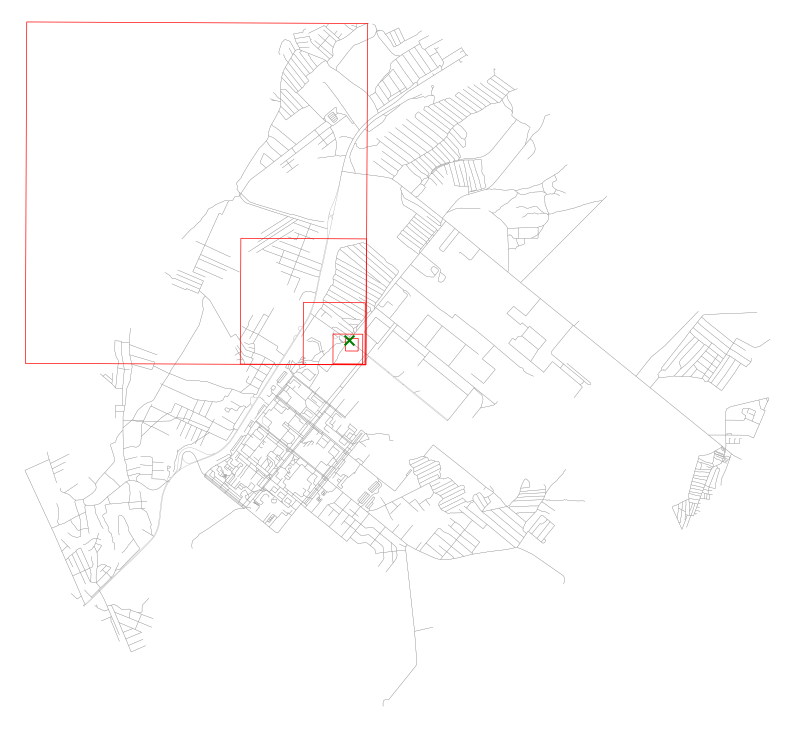

In [3]:
import random
import math

import shapely
from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.best_points import NodeMetric
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing

class BestNodeSquareZoom(BestPointsBase):
    """
    Поиск лучшего узла графа методом рекурсивного деления области на квадраты.
    1. Проекция графа в локальную систему координат.
    2. Определение главного прямоугольника, в который вписаны узлы графа.
    3. Разбиение прямоугольника на квадраты со стороной min(width, height)/2.
    4. В каждом квадрате случайная выборка до n узлов и вычисление метрики.
    5. Выбор квадрата с узлом наилучшей метрики и рекурсия, пока количество узлов в квадрате не <= n_min_count.
    """
    def __init__(self, state_function: StateBase,
                metric_function: MetricBase,
                n_samples: int = 10,
                n_min_count: int = 5,
                step_end_function: callable = None,
                **kwargs):
        """
        `state_function`: StateBase — функция расчета состояния окружения.
        `metric_function`: MetricBase — функция расчета метрики.
        `n_samples`: int — максимальное число узлов для оценки в каждом квадрате.
        `n_min_count`: int — минимальное число узлов для останова рекурсии.
        `step_end_function` - функция, вызываемая после каждого шага рекурсии.
        """
        self.n_samples = n_samples
        self.n_min_count = n_min_count
        self.step_end_function = step_end_function
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env: nx.Graph,
                area=None, 
                start_point: int = None,
                points_list: set = None,
                **kwargs) -> tuple[int | None, float | None]:
        """
        `env`: MultiDiGraph — граф улично-дорожной сети.
        `area`: pandas.Series — маска узлов графа для расчёта доступности (см. NodeMetric).
        `start_point`: не используется.
        `points_list`: set — начальный набор узлов-кандидатов.
        Возвращает `(best_node, best_metric)`.
        """
        # Подготовка исходных узлов
        if points_list is None:
            current_nodes = list(env.nodes())
        else:
            current_nodes = list(points_list)
        # Проекция графа
        # Проекция графа только если он в географической системе координат
        if env.graph['crs'] == 'epsg:4326':
            G = ox.project_graph(env)
        else:
            G = env
        node_metric_fn = NodeMetric(self.state_function, self.metric_function)
        best_node = None
        best_metric = None

        level = 1
        # best_squares = []
        while True:
            # Координаты узлов
            xs = [G.nodes[u]['x'] for u in current_nodes]
            ys = [G.nodes[u]['y'] for u in current_nodes]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            dx, dy = x_max - x_min, y_max - y_min
            size = min(dx, dy) / 2
            # Создание квадратов
            nx_squares = int(math.ceil(dx / size))
            ny_squares = int(math.ceil(dy / size))
            squares = []
            for i in range(nx_squares):
                for j in range(ny_squares):
                    x0, y0 = x_min + i * size, y_min + j * size
                    squares.append((x0, y0, x0 + size, y0 + size))
            # Оценка квадратов
            best_node_sq = None
            best_metric_sq = None
            best_square_nodes = None
            square = 1
            best_square = None
            for x0, y0, x1, y1 in squares:
                # Узлы в квадрате
                nodes_sq = [u for u in current_nodes if x0 <= G.nodes[u]['x'] <= x1 and y0 <= G.nodes[u]['y'] <= y1]
                if not nodes_sq:
                    continue
                # Выборка узлов
                if len(nodes_sq) > self.n_samples:
                    sample = random.sample(nodes_sq, self.n_samples)
                else:
                    sample = nodes_sq
                # Оценка узлов
                for u in sample:
                    node_metric = node_metric_fn(env=G, node=u, area=area, **kwargs)
                    if node_metric is None:
                        continue
                    if best_metric_sq is None or self.metric_function.compare(node_metric, best_metric_sq) == node_metric:
                        best_metric_sq = node_metric
                        best_node_sq = u
                        best_square_nodes = nodes_sq
                        best_square = (x0, y0, x1, y1)
                # print(f'square {square} - {best_node_sq}, {best_metric_sq}')
                square += 1
            # best_squares.append(best_square)
            if best_node_sq is None:
                break
            best_node, best_metric = best_node_sq, best_metric_sq
            # Проверка условия останова
            if len(best_square_nodes) <= self.n_min_count:
                break
            # Переход к узлам лучшего квадрата
            current_nodes = best_square_nodes
            # Печать результата
            if self.step_end_function is not None:
                self.step_end_function(
                    step        = level,
                    best_node   = best_node,
                    best_metric = best_metric,
                    best_square = best_square)
            # Уменьшение масштаба квадратов
            # print(f'level {level} - {best_node}, {best_metric}')
            level += 1

        return best_node, best_metric  #, best_squares


# ===============================================================
best_squares = []
def step_end_function(step, best_node, best_metric, best_square):
    print(f'step {step} - {best_node}, {best_metric}')
    best_squares.append(best_square)


# Инициализация алгоритма
blp = timing(BestNodeSquareZoom(
    state_function    = FirstArrivalUnitState(),
    metric_function   = ArrivalTime(),
    n_samples         = 10,
    n_min_count       = 5,
    step_end_function = step_end_function,
    ))

# Расчет лучшего размещения
best_node, best_metric = blp(env=G)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')


def plot_map(G, best_squares, ):
    # Визуализация ГДС с оптимальной точкой размещения и квадратами последовательного приближения
    geometry = [shapely.geometry.box(x0, y0, x1, y1) for x0, y0, x1, y1 in best_squares]

    boxes = gpd.GeoDataFrame(geometry, columns=['geometry'], crs=ox.project_graph(G).graph['crs'])
    boxes = ox.projection.project_gdf(boxes, to_latlong=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
    boxes.boundary.plot(ax=ax, color='red', linewidth=0.5)
    ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='g', marker='x', 
                                                        markersize=50, zorder=10)
    plt.show()

plot_map(G, best_squares)

<span style="color: red">Важно:</style> Квадраты уменьшаются потому что строится он исходя из точек размещения узлов. Понятно, что узлы не всегда (почти никогда) не находятся на границах квадратов.

step 1 - 1555148571, 4.739470318634651
step 2 - 1545616088, 4.604846178012644
step 3 - 1998227479, 4.370706591896035
step 4 - 9085465253, 4.47270907500479
step 5 - 1998227467, 4.35872365256402
ВРЕМЯ: 21.91 сек
Наиболее выгодная точка размещения: 1550088187
Среднее время следования в любую точку города: 4.3542845536432715 мин


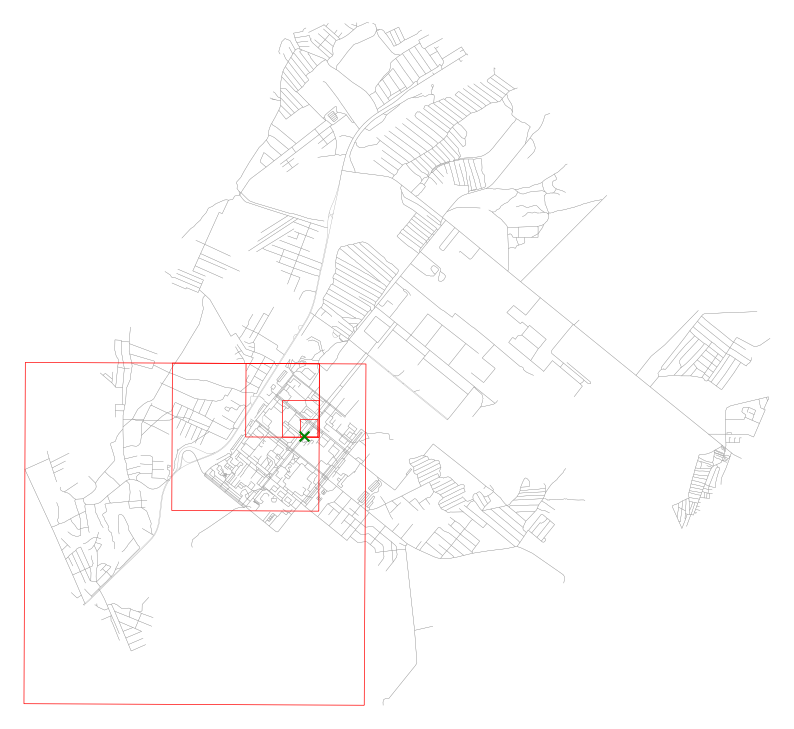

In [4]:
# Расчет лучшего размещения
best_squares = []
best_node, best_metric = blp(env=G, area=area_nodes)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

plot_map(G, best_squares)

|########################################| 100.0%
Наиболее выгодные точки размещения: 426923808
Среднее время следования в любую точку города: 8.355415617070701 мин
|########################################| 100.0%
Наиболее выгодные точки размещения: 1577701962
Среднее время следования в любую точку города: 4.328401644772975 мин


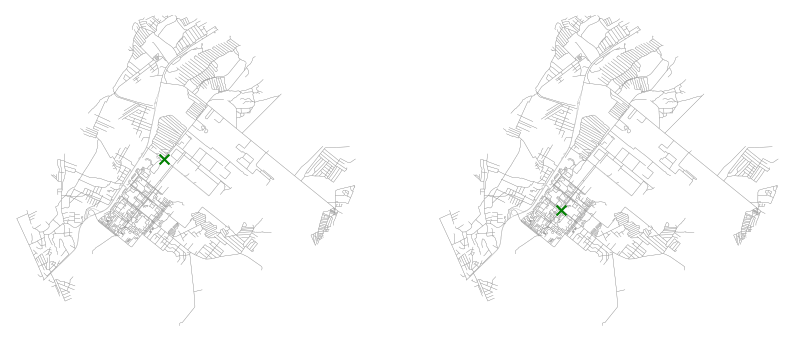

In [12]:
from genesis.best_points import BestNodesFull
from genesis.utils import Progressbar, timing


# Расчет лучшего размещения
full = timing(BestNodesFull(
    state_function = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    node_calc_end_function = Progressbar(G.number_of_nodes())
))
best_node, best_metric = full(G)
# Печать результата
print('Наиболее выгодные точки размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Расчет лучшего размещения в области
full = timing(BestNodesFull(
    state_function = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    node_calc_end_function = Progressbar(G.number_of_nodes())
))
best_node_a, best_metric_a = full(G, area=area_nodes)
# Печать результата
print('Наиболее выгодные точки размещения:', best_node_a)
print('Среднее время следования в любую точку города:', best_metric_a, 'мин')


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 10))

ox.plot_graph(G, ax=ax1, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax1, color='g', marker='x', 
                                                    markersize=50, zorder=10)

ox.plot_graph(G, ax=ax2, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node_a]].plot(ax=ax2, color='g', marker='x', 
                                                    markersize=50, zorder=10)

plt.show()

# Алгоритм вложенных окружностей

Дан граф улично-дорожной сети в формате `networkx.MultiDiGraph`, веса ребер определены полем `travel_time` и представляют время следования по участку дороги в минутах. Напиши программный код Python для следующего алгоритма определения лучшего узла:

1. Граф проецируется в локальную систему координат при помощи `osmnx.project_graph`.
2. Определяется окружность в которую вписаны все узлы графа
3. В пределах окружности определяется `n` узлов, для каждого из них при помощи `genesis.Best_points.NodeMetric` определяется значение метрики времени среднего времени прибытия `genesis.metrics.ArrivalTime`.
4. Выбирается узел с наилучшей метрикой
5. Строится окружность с радиусом вдвое меньше предыдущей и центром в наилучшем узле
6. Если в пределах окружности содержится больше узлов чем некоторое минимальное значение `n_min_count` задаваемое как гиперпараметр алгоритма, то шаги 3,4,5,6 повторяются
7. Алгоритм возвращает узел с лучшей метрикой.

Алгоритм должен быть реализован как наследник класса `genesis.core.BestPointsBase` и реализовывать соответсвующий интерфейс. Примеры разработки алгоритмов как наследников `genesis.core.BestPointsBase` посмотри в файле `genesis.best_points.py`.

Пример реализации алгоритма на основе класса `genesis.core.BestPointsBase` приведен в прилагаемом коде.

step 1 - 9086101136, 8.532553133435425
step 2 - 9086101136, 8.532553133435425
step 3 - 1555142677, 8.503940478924418
step 4 - 1555142677, 8.503940478924418
step 5 - 1555142677, 8.503940478924418
step 6 - 1577701960, 8.502387347682204
step 7 - 1577701960, 8.502387347682204
step 8 - 1577701960, 8.502387347682204
step 9 - 1577701960, 8.502387347682204
ВРЕМЯ: 12.45 сек
Наиболее выгодная точка размещения: 1577701960
Среднее время следования в любую точку города: 8.502387347682204 мин


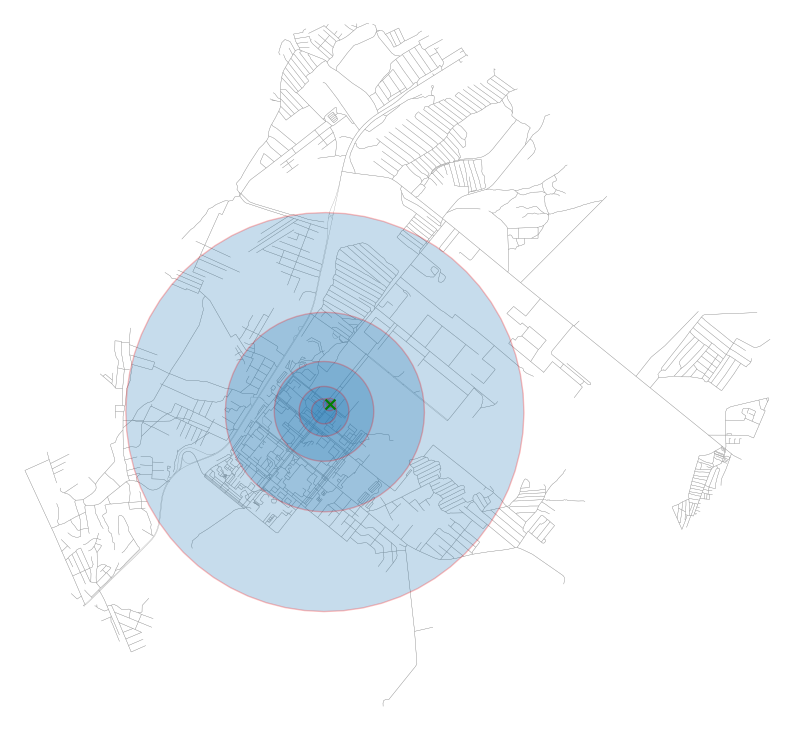

In [5]:
import random
import math

from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.best_points import NodeMetric
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing
from shapely import Point


class BestNodeCircleZoom(BestPointsBase):
    """
    Поиск лучшего узла графа методом рекурсивного деления области на вложенные окружности.
    1. Проекция графа в локальную систему координат.
    2. Определение окружности, в которую вписаны все узлы графа.
    3. В пределах окружности случайная выборка до n узлов и вычисление метрики.
    4. Выбор узла с наилучшей метрикой.
    5. Построение окружности с радиусом вдвое меньше предыдущего и центром в наилучшем узле.
    6. Повторять шаги 3-5, пока количество узлов в окружности не <= n_min_count.
    """
    def __init__(self, 
                 state_function:    StateBase,
                 metric_function:   MetricBase,
                 n_samples:         int      = 10,
                 n_min_count:       int      = 5,
                 step_end_function: callable = None,
                 **kwargs):
        self.n_samples = n_samples
        self.n_min_count = n_min_count
        self.step_end_function = step_end_function
        super().__init__(state_function, metric_function, **kwargs)
    
    def __call__(self,
                 env:         nx.Graph,
                 area                  = None,
                 start_point: int      = None,
                 points_list: set      = None,
                 **kwargs) -> tuple[int | None, float | None]:
        # Подготовка исходных узлов
        if points_list is None:
            current_nodes = list(env.nodes())
        else:
            current_nodes = list(points_list)
        # Проекция графа
        if env.graph.get('crs') == 'epsg:4326':
            G = ox.project_graph(env)
        else:
            G = env
        # Координаты узлов
        xs = [G.nodes[u]['x'] for u in current_nodes]
        ys = [G.nodes[u]['y'] for u in current_nodes]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        # Центр и радиус окружности
        center_x = (x_min + x_max) / 2
        center_y = (y_min + y_max) / 2
        radius = max(math.hypot(G.nodes[u]['x'] - center_x,
                                G.nodes[u]['y'] - center_y)
                     for u in current_nodes)
        node_metric_fn = NodeMetric(self.state_function, self.metric_function)
        best_node = None
        best_metric = None
        level = 1
        current_center = (center_x, center_y)
        current_radius = radius
        while True:
            # Узлы внутри текущей окружности
            circle_nodes = [u for u in current_nodes
                            if math.hypot(G.nodes[u]['x'] - current_center[0],
                                          G.nodes[u]['y'] - current_center[1])
                            <= current_radius]
            if not circle_nodes:
                break
            # Случайная выборка узлов
            if len(circle_nodes) > self.n_samples:
                sample = random.sample(circle_nodes, self.n_samples)
            else:
                sample = circle_nodes
            # Оценка узлов в выборке
            for u in sample:
                m = node_metric_fn(env=G, node=u, area=area, **kwargs)
                if m is None:
                    continue
                if best_metric is None or \
                   self.metric_function.compare(m, best_metric) == m:
                    best_metric = m
                    best_node = u
            if best_node is None:
                break
            # Условие останова
            if len(circle_nodes) <= self.n_min_count:
                break
            # Обновление центра и радиуса
            current_center = (G.nodes[best_node]['x'], G.nodes[best_node]['y'])
            current_radius /= 2
            # Вызов функции после шага
            if self.step_end_function:
                self.step_end_function(
                    step        = level,
                    best_node   = best_node,
                    best_metric = best_metric,
                    center      = current_center,
                    radius      = current_radius)
            level += 1
        return best_node, best_metric
    


# ===============================================================
circles = []
def step_end_function(step, best_node, best_metric, center, radius):
    print(f'step {step} - {best_node}, {best_metric}')
    circles.append((center, radius))


# Инициализация алгоритма
blp = timing(BestNodeCircleZoom(
    state_function    = FirstArrivalUnitState(),
    metric_function   = ArrivalTime(),
    n_samples         = 20,
    n_min_count       = 5,
    step_end_function = step_end_function,
    ))

# Расчет лучшего размещения
best_node, best_metric = blp(env=G)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')


def plot_map(G, circles, ):
    # Визуализация ГДС с оптимальной точкой размещения и квадратами последовательного приближения
    geometry = [
        Point(xy).buffer(r)   # по умолчанию разбивка буфера ~64 сегмента, можно настроить second argument
        for xy, r in circles
    ]

    # boxes = gpd.GeoDataFrame(geometry, columns=['geometry'], crs=ox.project_graph(G).graph['crs'])
    # boxes = ox.projection.project_gdf(boxes, to_latlong=True)

    circles_gdf = gpd.GeoDataFrame(geometry,
                                   columns=['geometry'],
                                   crs=ox.project_graph(G).graph['crs'])
    circles_gdf = ox.projection.project_gdf(circles_gdf, to_latlong=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
    # circles_gdf.boundary.plot(ax=ax, color='red', linewidth=0.5)
    circles_gdf.plot(ax=ax, alpha=0.25, edgecolor='r')
    ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='g', marker='x', 
                                                        markersize=50, zorder=10)
    plt.show()

plot_map(G, circles)

In [6]:
blp = timing(BestNodeCircleZoom(
    state_function    = FirstArrivalUnitState(),
    metric_function   = ArrivalTime(),
    n_samples         = 20,
    n_min_count       = 5,
    # step_end_function = step_end_function,
    ))

for i in range(10):
    # Расчет лучшего размещения
    best_node, best_metric = blp(env=G)
    print(f'Расчет № {i+1}', best_node, best_metric)

ВРЕМЯ: 11.31 сек
Расчет № 1 1297042721 8.450087963377285
ВРЕМЯ: 11.71 сек
Расчет № 2 426923808 8.355415617070701
ВРЕМЯ: 11.18 сек
Расчет № 3 1297042721 8.450087963377285
ВРЕМЯ: 11.37 сек
Расчет № 4 426923808 8.355415617070701
ВРЕМЯ: 11.19 сек
Расчет № 5 1550153892 8.474457579993771
ВРЕМЯ: 11.66 сек
Расчет № 6 426923808 8.355415617070701
ВРЕМЯ: 12.29 сек
Расчет № 7 1577701960 8.502387347682204
ВРЕМЯ: 11.73 сек
Расчет № 8 426923808 8.355415617070701
ВРЕМЯ: 11.3 сек
Расчет № 9 426923808 8.355415617070701
ВРЕМЯ: 11.29 сек
Расчет № 10 426923808 8.355415617070701


In [8]:
# Инициализация алгоритма
blp = timing(BestNodeSquareZoom(
    state_function    = FirstArrivalUnitState(),
    metric_function   = ArrivalTime(),
    n_samples         = 20,
    n_min_count       = 5,
    # step_end_function = step_end_function,
    ))

# Расчет лучшего размещения
for i in range(10):
    # Расчет лучшего размещения
    best_node, best_metric = blp(env=G)
    print(f'Расчет № {i+1}', best_node, best_metric)

ВРЕМЯ: 33.7 сек
Расчет № 1 426923808 8.355415617070701
ВРЕМЯ: 33.7 сек
Расчет № 2 426923808 8.355415617070701
ВРЕМЯ: 34.93 сек
Расчет № 3 426923808 8.355415617070701
ВРЕМЯ: 34.8 сек
Расчет № 4 426923808 8.355415617070701
ВРЕМЯ: 34.66 сек
Расчет № 5 426923808 8.355415617070701
ВРЕМЯ: 34.87 сек
Расчет № 6 426923808 8.355415617070701
ВРЕМЯ: 34.97 сек
Расчет № 7 426923808 8.355415617070701
ВРЕМЯ: 34.82 сек
Расчет № 8 426923808 8.355415617070701
ВРЕМЯ: 34.54 сек
Расчет № 9 426923808 8.355415617070701
ВРЕМЯ: 34.37 сек
Расчет № 10 426923808 8.355415617070701


<span style='color:red'>Очень важно количество примеров!</span>